# 01 · Keşifsel Veri Analizi (EDA)

**Amaç:** PM2.5 tahmin modelini kurmadan önce verinin yapısını anlamak ve modelleme kararlarını
(özellikler, doğrulama şeması, hedef dönüşümü, uyarı eşiği) veriye dayandırmak.

**Veri:** `data/processed/all_cities.parquet`. 5 şehir, 2023-01-01 → 2026-09-17, saatlik
(Open-Meteo: CAMS kirletici modeli + ERA5 meteoroloji). Üretmek için: `make data && make process`.

> Not: Kirletici değerleri istasyon ölçümü değil, ~11 km çözünürlüklü CAMS modelinin çıktısıdır.
> Bulgular bu modelin davranışını yansıtır.

**İçerik**
1. Genel bakış ve hedef dağılımı
2. Mevsimsellik (ay × saat)
3. Günlük döngü (mevsime göre)
4. Haftalık döngü
5. Sıcaklık ve kış ısınma etkisi
6. Rüzgâr hızı ve yönü
7. Yağışın etkisi
8. Değişkenler arası korelasyon
9. Otokorelasyon (ACF/PACF)
10. Şehirler arası gecikmeli ilişki
11. Kirlilik epizotları ve uyarı kalıcılığı
12. Özet bulgular ve modelleme kararları

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

from havauyari.config import POLLUTANTS, ROOT, TARGET, WEATHER_VARS
from havauyari.data.clean import PROCESSED_PATH

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 90, "savefig.dpi": 120, "savefig.bbox": "tight"})
pd.set_option("display.precision", 2)

CITY_ORDER = ["istanbul", "ankara", "izmir", "bursa", "kocaeli"]
CITY_LABEL = {"istanbul": "İstanbul", "ankara": "Ankara", "izmir": "İzmir",
              "bursa": "Bursa", "kocaeli": "Kocaeli"}
PALETTE = dict(zip(CITY_ORDER, sns.color_palette("tab10", 5)))
SEASONS = ["Kış", "İlkbahar", "Yaz", "Sonbahar"]
SEASON_OF = {12: "Kış", 1: "Kış", 2: "Kış", 3: "İlkbahar", 4: "İlkbahar", 5: "İlkbahar",
             6: "Yaz", 7: "Yaz", 8: "Yaz", 9: "Sonbahar", 10: "Sonbahar", 11: "Sonbahar"}
SENSITIVE, UNHEALTHY = 35.5, 55.5  # AQI eşikleri (µg/m³)


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")


df = pd.read_parquet(PROCESSED_PATH).rename_axis("time")
df["city"] = pd.Categorical(df["city"], CITY_ORDER)
df["hour"] = df.index.hour
df["month"] = df.index.month
df["dow"] = df.index.dayofweek
df["season"] = df["month"].map(SEASON_OF)
by_city = {c: g for c, g in df.groupby("city", observed=True)}
print(df.shape, df.index.min(), "->", df.index.max())

(162720, 17) 2023-01-01 00:00:00 -> 2026-09-17 23:00:00


## 1. Genel bakış ve hedef dağılımı

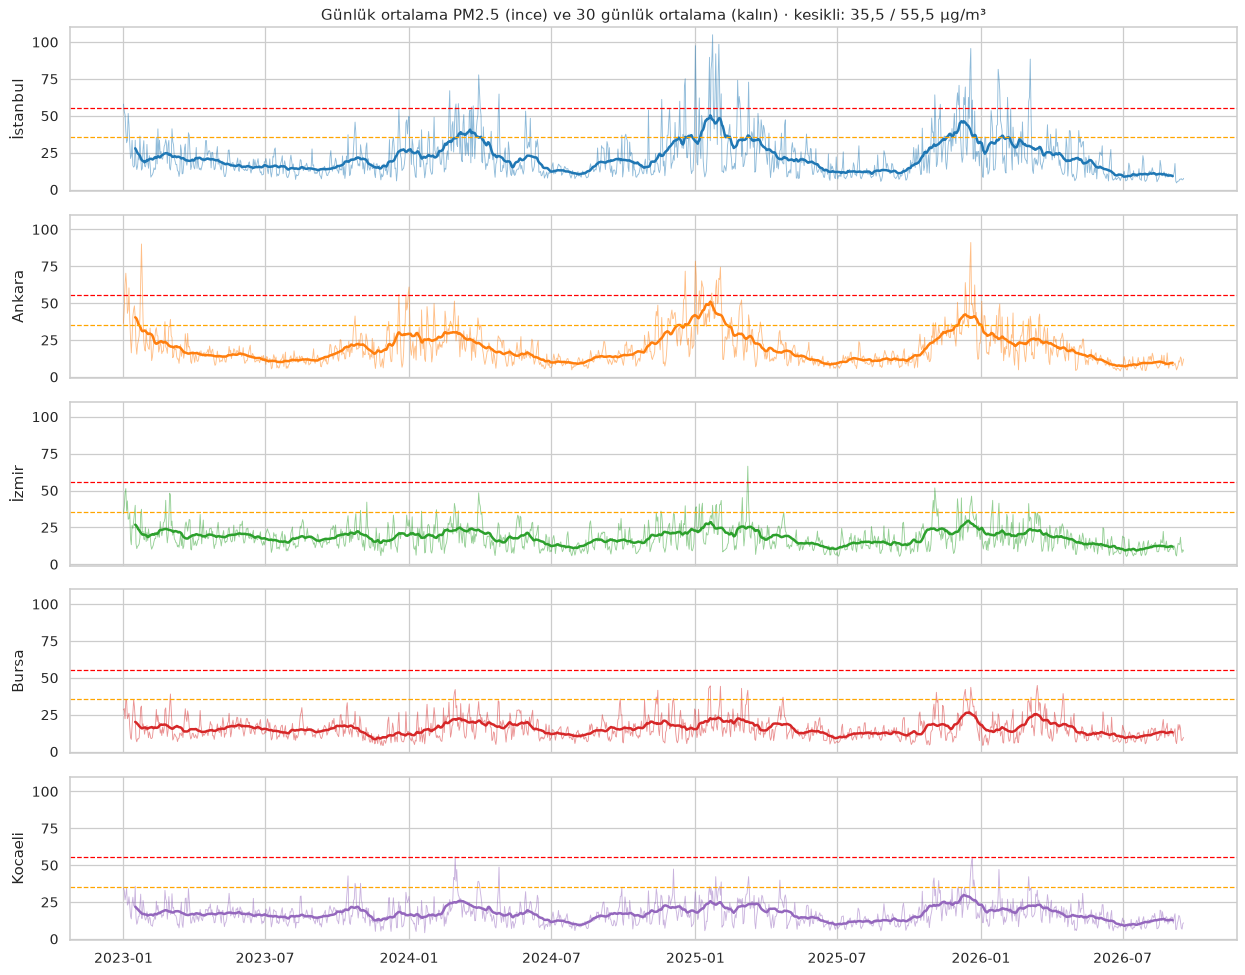

In [2]:
daily = df.groupby("city", observed=True)[TARGET].resample("D").mean().unstack(0)
fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True, sharey=True)
for ax, c in zip(axes, CITY_ORDER):
    ax.plot(daily.index, daily[c], color=PALETTE[c], lw=0.7, alpha=0.5)
    ax.plot(daily.index, daily[c].rolling(30, center=True).mean(), color=PALETTE[c], lw=2)
    ax.axhline(SENSITIVE, color="orange", ls="--", lw=1)
    ax.axhline(UNHEALTHY, color="red", ls="--", lw=1)
    ax.set_ylabel(CITY_LABEL[c])
axes[0].set_title("Günlük ortalama PM2.5 (ince) ve 30 günlük ortalama (kalın) · kesikli: 35,5 / 55,5 µg/m³")
fig.tight_layout()
save(fig, "01_zaman_serisi")

,çarpıklık (ham),çarpıklık (log1p)
İstanbul,3.23,0.71
Ankara,2.50,0.54
İzmir,1.89,0.29
Bursa,1.84,0.21
Kocaeli,1.39,0.02


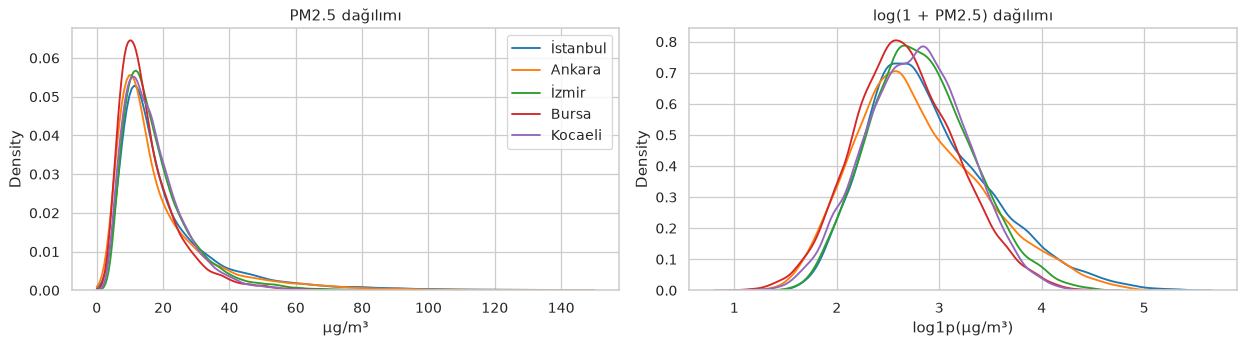

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for c in CITY_ORDER:
    s = by_city[c][TARGET]
    sns.kdeplot(s, ax=axes[0], label=CITY_LABEL[c], color=PALETTE[c], clip=(0, 150))
    sns.kdeplot(np.log1p(s), ax=axes[1], label=CITY_LABEL[c], color=PALETTE[c])
axes[0].set(title="PM2.5 dağılımı", xlabel="µg/m³")
axes[1].set(title="log(1 + PM2.5) dağılımı", xlabel="log1p(µg/m³)")
axes[0].legend()
fig.tight_layout()
save(fig, "01_dagilim")

skew = pd.DataFrame({CITY_LABEL[c]: {"çarpıklık (ham)": by_city[c][TARGET].skew(),
                                     "çarpıklık (log1p)": np.log1p(by_city[c][TARGET]).skew()}
                     for c in CITY_ORDER}).T
skew

## 2. Mevsimsellik (ay × saat)

,Kış medyanı,Yaz medyanı,Kış / Yaz
İstanbul,21.7,11.6,1.87
Ankara,26.2,9.9,2.65
İzmir,18.6,12.8,1.45
Bursa,13.9,11.8,1.18
Kocaeli,18.1,11.9,1.52


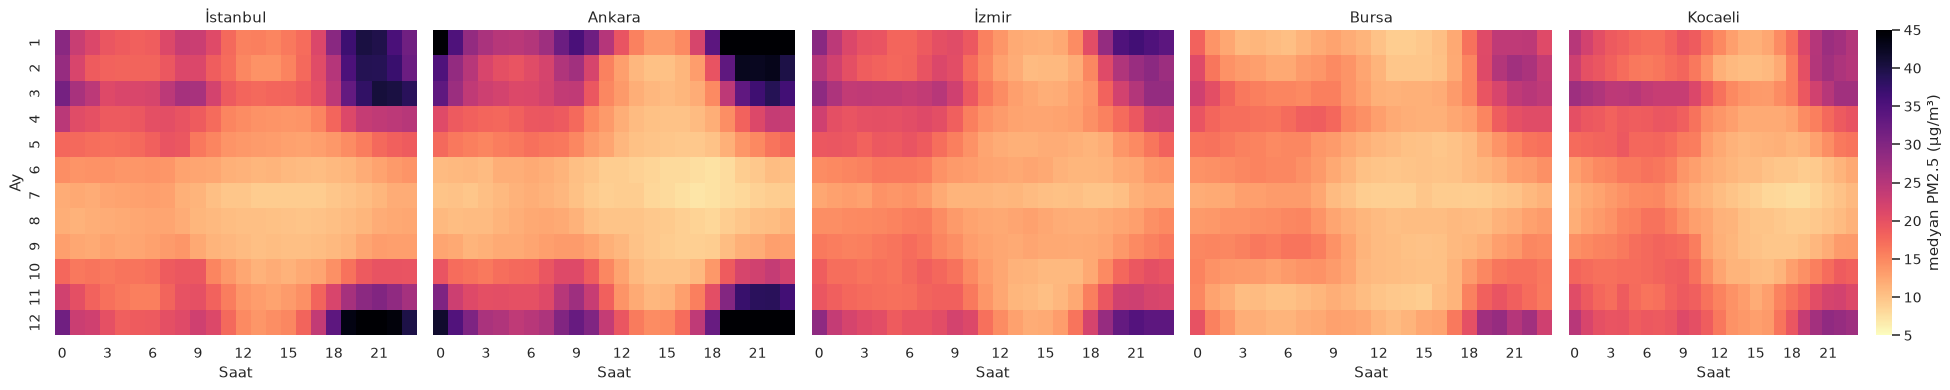

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)
for ax, c in zip(axes, CITY_ORDER):
    pv = by_city[c].pivot_table(index="month", columns="hour", values=TARGET, aggfunc="median")
    sns.heatmap(pv, ax=ax, cmap="magma_r", vmin=5, vmax=45, cbar=c == CITY_ORDER[-1],
                cbar_kws={"label": "medyan PM2.5 (µg/m³)"})
    ax.set_title(CITY_LABEL[c])
    ax.set_xlabel("Saat")
    ax.set_ylabel("Ay" if c == CITY_ORDER[0] else "")
    ax.set_xticks(np.arange(0, 24, 3) + 0.5, labels=range(0, 24, 3), rotation=0)
fig.tight_layout()
save(fig, "02_ay_saat_isi_haritasi")

winter_summer = pd.DataFrame({
    CITY_LABEL[c]: {"Kış medyanı": by_city[c].loc[by_city[c].season == "Kış", TARGET].median(),
                    "Yaz medyanı": by_city[c].loc[by_city[c].season == "Yaz", TARGET].median()}
    for c in CITY_ORDER}).T
winter_summer["Kış / Yaz"] = winter_summer["Kış medyanı"] / winter_summer["Yaz medyanı"]
winter_summer

## 3. Günlük döngü (mevsime göre)

,kış zirve saati,kış dip saati,zirve / dip
İstanbul,20.0,13.0,2.88
Ankara,21.0,14.0,4.34
İzmir,22.0,15.0,2.91
Bursa,21.0,14.0,2.63
Kocaeli,21.0,15.0,2.40


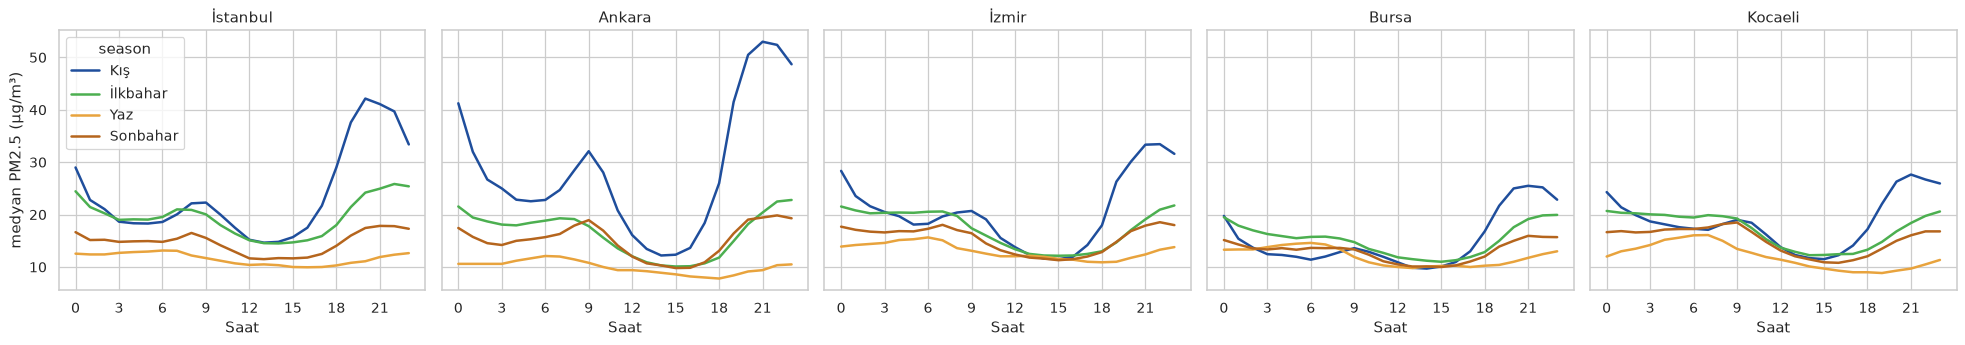

In [5]:
colors = ["#1f4e9c", "#4caf50", "#e8a33d", "#b5651d"]
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
peaks = {}
for ax, c in zip(axes, CITY_ORDER):
    prof = by_city[c].groupby(["season", "hour"])[TARGET].median().unstack(0)[SEASONS]
    prof.plot(ax=ax, lw=2, color=colors, legend=c == CITY_ORDER[0])
    ax.set(title=CITY_LABEL[c], xlabel="Saat", ylabel="medyan PM2.5 (µg/m³)", xticks=range(0, 24, 3))
    w = prof["Kış"]
    peaks[CITY_LABEL[c]] = {"kış zirve saati": w.idxmax(), "kış dip saati": w.idxmin(),
                            "zirve / dip": w.max() / w.min()}
fig.tight_layout()
save(fig, "03_gunluk_dongu")
pd.DataFrame(peaks).T

## 4. Haftalık döngü

,Pzt,Sal,Çar,Per,Cum,Cmt,Paz
İstanbul,99.23,102.00,102.79,105.83,103.96,92.84,93.34
Ankara,99.13,103.37,103.99,103.47,102.87,95.69,91.49
İzmir,98.13,102.70,105.25,102.90,102.46,94.09,94.47
Bursa,96.95,100.08,103.55,105.55,101.94,96.80,95.14
Kocaeli,96.51,100.53,102.64,104.46,102.96,97.19,95.72


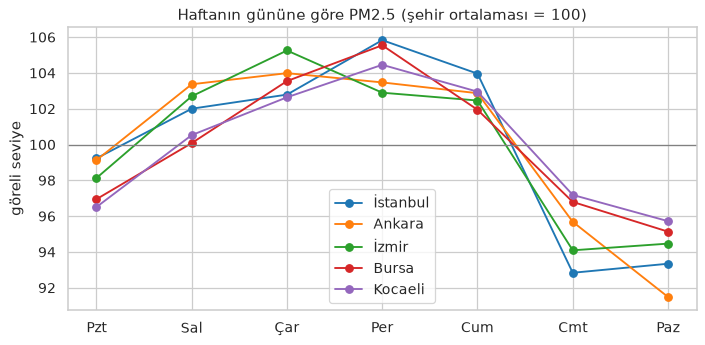

In [6]:
dow = df.groupby(["city", "dow"], observed=True)[TARGET].mean().unstack(0)
rel = dow / dow.mean() * 100
rel.index = ["Pzt", "Sal", "Çar", "Per", "Cum", "Cmt", "Paz"]
rel.columns = [CITY_LABEL[c] for c in rel.columns]
fig, ax = plt.subplots(figsize=(8, 4))
rel.plot(ax=ax, marker="o", color=[PALETTE[c] for c in CITY_ORDER])
ax.axhline(100, color="grey", lw=1)
ax.set(title="Haftanın gününe göre PM2.5 (şehir ortalaması = 100)", ylabel="göreli seviye")
fig.tight_layout()
save(fig, "04_haftalik")
rel.T

## 5. Sıcaklık ve kış ısınma etkisi

Sıcaklık–PM2.5 Spearman korelasyonu (mevsim içinde):


,Kış,İlkbahar,Yaz,Sonbahar
İstanbul,5.94e-03,-0.08,-0.11,-0.21
Ankara,-2.76e-01,-0.22,-0.12,-0.35
İzmir,-1.79e-01,-0.21,-0.21,-0.20
Bursa,-2.78e-01,-0.17,-0.22,-0.07
Kocaeli,-5.83e-02,-0.17,-0.18,-0.20


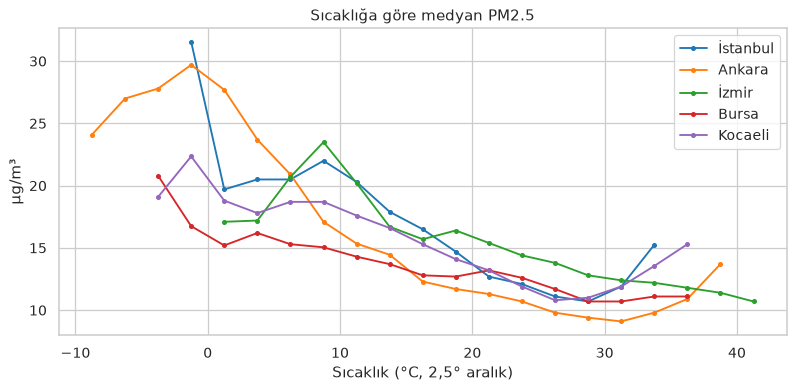

In [7]:
bins = np.arange(-15, 45, 2.5)
t = (df.assign(temp_bin=pd.cut(df["temperature_2m"], bins))
       .groupby(["city", "temp_bin"], observed=True)[TARGET].agg(["median", "size"]).reset_index())
t = t[t["size"] >= 50]
t["sıcaklık"] = t["temp_bin"].apply(lambda b: b.mid).astype(float)
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in CITY_ORDER:
    s = t[t.city == c]
    ax.plot(s["sıcaklık"], s["median"], marker="o", ms=3, color=PALETTE[c], label=CITY_LABEL[c])
ax.set(title="Sıcaklığa göre medyan PM2.5", xlabel="Sıcaklık (°C, 2,5° aralık)", ylabel="µg/m³")
ax.legend()
fig.tight_layout()
save(fig, "05_sicaklik")

rho = {CITY_LABEL[c]: {s: by_city[c].loc[by_city[c].season == s, [TARGET, "temperature_2m"]]
                          .corr("spearman").iloc[0, 1] for s in SEASONS} for c in CITY_ORDER}
print("Sıcaklık–PM2.5 Spearman korelasyonu (mevsim içinde):")
pd.DataFrame(rho).T

## 6. Rüzgâr hızı ve yönü

ws,"(-0.001, 2.0]","(2.0, 4.0]","(4.0, 6.0]","(6.0, 8.0]","(8.0, 10.0]","(10.0, 15.0]","(15.0, 20.0]","(20.0, 60.0]"
İstanbul,33.6,29.4,27.2,24.2,19.6,14.9,12.1,10.90
Ankara,26.1,20.4,15.9,13.9,11.7,9.7,8.4,8.65
İzmir,25.3,22.3,20.5,17.3,15.3,12.6,10.5,9.70
Bursa,18.8,16.3,14.5,12.9,11.4,9.4,8.0,7.70
Kocaeli,20.5,19.2,17.4,15.6,13.2,11.0,9.2,8.00


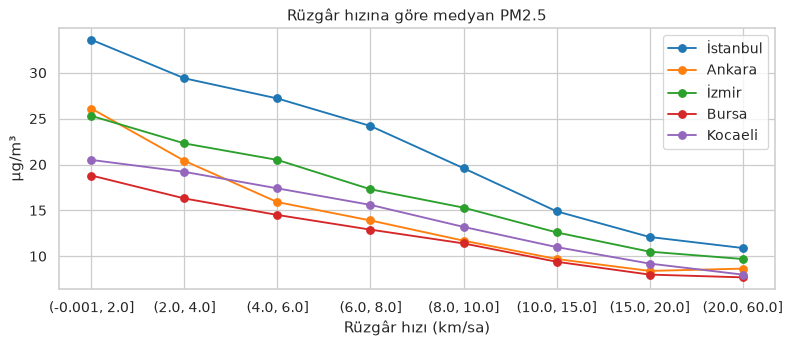

In [8]:
ws_bins = [0, 2, 4, 6, 8, 10, 15, 20, 60]
w = (df.assign(ws=pd.cut(df["wind_speed_10m"], ws_bins, include_lowest=True))
       .groupby(["city", "ws"], observed=True)[TARGET].median().unstack(0))
w.columns = [CITY_LABEL[c] for c in w.columns]
fig, ax = plt.subplots(figsize=(9, 4))
w.plot(ax=ax, marker="o", color=[PALETTE[c] for c in CITY_ORDER])
ax.set(title="Rüzgâr hızına göre medyan PM2.5", xlabel="Rüzgâr hızı (km/sa)", ylabel="µg/m³")
fig.tight_layout()
save(fig, "06_ruzgar_hizi")
w.T

,en kirli yön,ort. PM2.5,en temiz yön,ort. PM2.5
İstanbul,DGD,43.67,KD,15.62
Ankara,DGD,33.62,KKD,13.91
İzmir,D,31.53,KKD,14.17
Bursa,G,19.94,KD,11.53
Kocaeli,KB,22.53,DKD,13.98


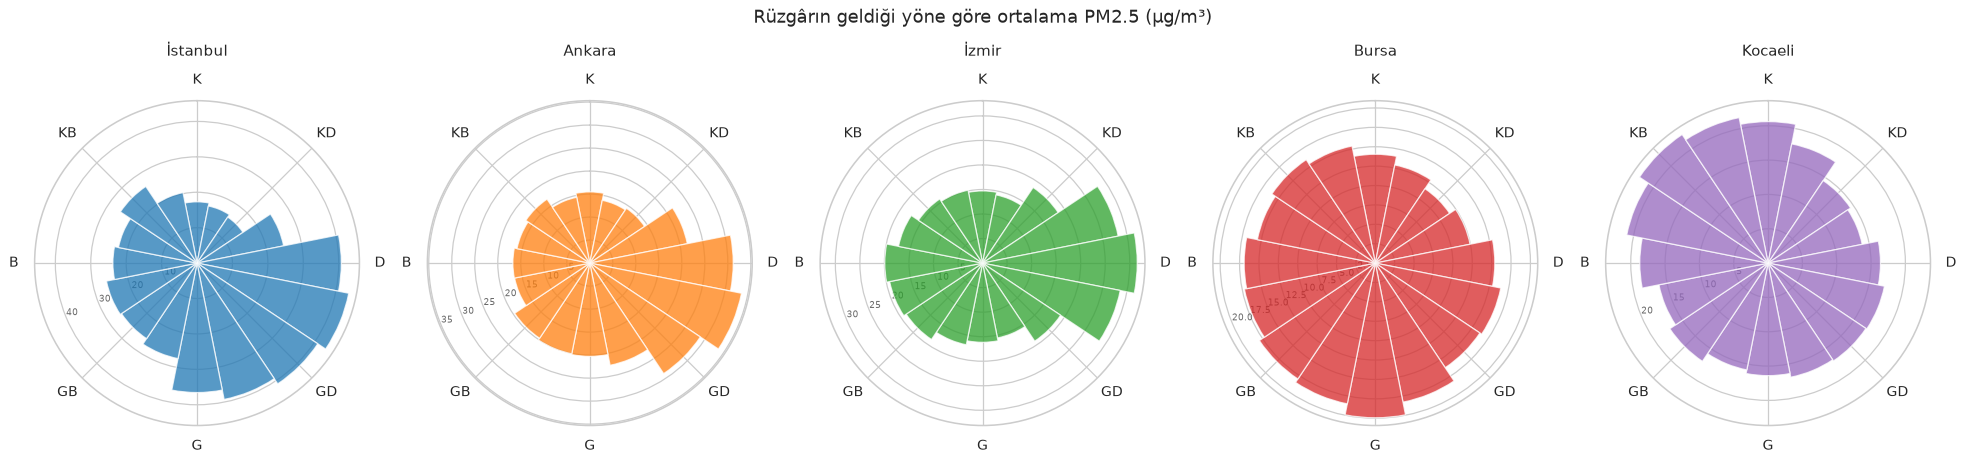

In [9]:
SECTORS = ["K", "KKD", "KD", "DKD", "D", "DGD", "GD", "GGD", "G", "GGB", "GB", "BGB", "B", "BKB", "KB", "KKB"]
sector = ((df["wind_direction_10m"] + 11.25) // 22.5 % 16).astype(int)
wd = df.assign(sector=sector).groupby(["city", "sector"], observed=True)[TARGET].mean().unstack(0)
theta = np.deg2rad(np.arange(16) * 22.5)
fig, axes = plt.subplots(1, 5, figsize=(22, 4.8), subplot_kw={"projection": "polar"})
worst = {}
for ax, c in zip(axes, CITY_ORDER):
    ax.bar(theta, wd[c].reindex(range(16)), width=np.deg2rad(22.5), color=PALETTE[c], alpha=0.75)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(theta[::2], labels=SECTORS[::2])
    ax.set_rlabel_position(247.5)
    ax.tick_params(axis="y", labelsize=7, labelcolor="dimgray")
    ax.set_title(CITY_LABEL[c], pad=14)
    worst[CITY_LABEL[c]] = {"en kirli yön": SECTORS[wd[c].idxmax()], "ort. PM2.5": wd[c].max(),
                            "en temiz yön": SECTORS[wd[c].idxmin()], "ort. PM2.5 ": wd[c].min()}
fig.suptitle("Rüzgârın geldiği yöne göre ortalama PM2.5 (µg/m³)", y=1.02)
fig.tight_layout()
save(fig, "06_ruzgar_yonu")
pd.DataFrame(worst).T

## 7. Yağışın etkisi

In [10]:
rows = {}
for c in CITY_ORDER:
    g = by_city[c]
    rain3 = g["precipitation"].rolling(3, min_periods=1).sum()
    rows[CITY_LABEL[c]] = {
        "kuru saat medyanı": g.loc[rain3 < 0.1, TARGET].median(),
        "yağışlı (son 3 saat) medyan": g.loc[rain3 >= 0.1, TARGET].median(),
        "yağışlı saat oranı %": (rain3 >= 0.1).mean() * 100,
    }
rain = pd.DataFrame(rows).T
rain["değişim %"] = (rain["yağışlı (son 3 saat) medyan"] / rain["kuru saat medyanı"] - 1) * 100
rain

,kuru saat medyanı,yağışlı (son 3 saat) medyan,yağışlı saat oranı %,değişim %
İstanbul,16.2,13.5,18.41,-16.67
Ankara,14.5,12.0,15.18,-17.24
İzmir,15.8,12.6,11.96,-20.25
Bursa,13.8,10.9,18.89,-21.01
Kocaeli,16.1,12.0,22.12,-25.47


## 8. Değişkenler arası korelasyon
Şehirleri birleştirmek şehirler arası seviye farklarından sahte korelasyon üretebileceği için her
şehirde ayrı Spearman korelasyonu hesaplanıp ortalaması alınır.

,PM2.5 ile ρ
pm10,0.96
sulphur_dioxide,0.75
nitrogen_dioxide,0.74
carbon_monoxide,0.72
ozone,-0.59
wind_speed_10m,-0.52
relative_humidity_2m,0.38
temperature_2m,-0.35
surface_pressure,0.17
precipitation,-0.15


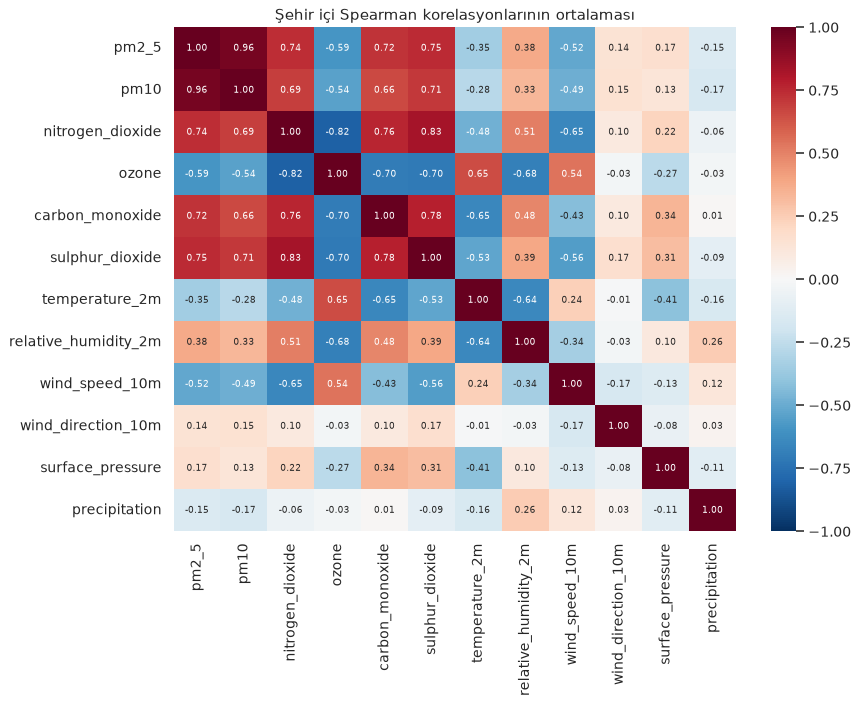

In [11]:
cols = POLLUTANTS + WEATHER_VARS
corr = sum(by_city[c][cols].corr("spearman") for c in CITY_ORDER) / len(CITY_ORDER)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7})
ax.set_title("Şehir içi Spearman korelasyonlarının ortalaması")
fig.tight_layout()
save(fig, "08_korelasyon")
corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).to_frame("PM2.5 ile ρ")

## 9. Otokorelasyon (ACF / PACF)

,lag 1,lag 3,lag 6,lag 12,lag 24,lag 48,lag 72,lag 168
İstanbul,0.96,0.79,0.55,0.45,0.60,0.44,0.40,0.36
Ankara,0.96,0.77,0.50,0.49,0.75,0.64,0.58,0.52
İzmir,0.96,0.80,0.54,0.41,0.62,0.45,0.38,0.34
Bursa,0.97,0.83,0.60,0.44,0.62,0.46,0.34,0.28
Kocaeli,0.97,0.84,0.65,0.50,0.62,0.45,0.37,0.30


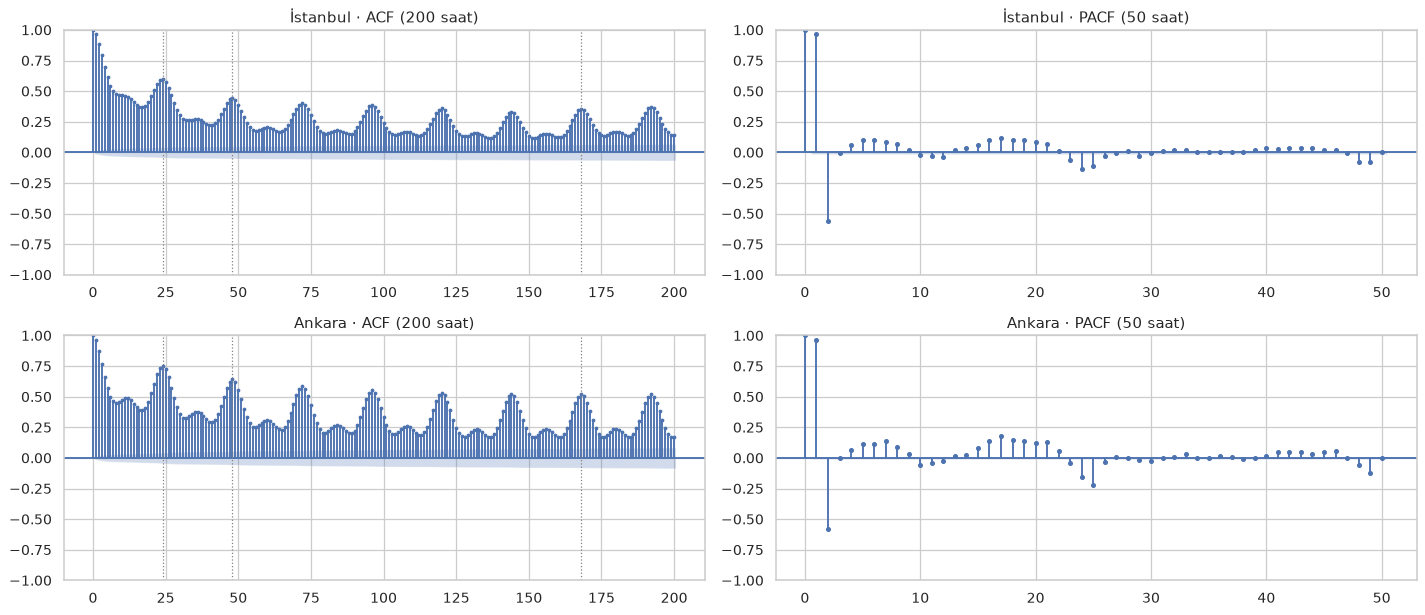

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 7))
for i, c in enumerate(["istanbul", "ankara"]):
    s = by_city[c][TARGET]
    plot_acf(s, lags=200, ax=axes[i, 0], markersize=2, title=f"{CITY_LABEL[c]} · ACF (200 saat)")
    plot_pacf(s, lags=50, ax=axes[i, 1], method="ywm", markersize=3,
              title=f"{CITY_LABEL[c]} · PACF (50 saat)")
    for x in (24, 48, 168):
        axes[i, 0].axvline(x, color="grey", ls=":", lw=1)
fig.tight_layout()
save(fig, "09_acf_pacf")

LAGS = [1, 3, 6, 12, 24, 48, 72, 168]
acf_tab = pd.DataFrame({CITY_LABEL[c]: acf(by_city[c][TARGET], nlags=168, fft=True)[LAGS]
                        for c in CITY_ORDER}, index=[f"lag {k}" for k in LAGS]).T
acf_tab

## 10. Şehirler arası gecikmeli ilişki
Tüm şehirler aynı günlük döngüyü paylaştığı için ham saatlik korelasyon yanıltıcı olur. Bu yüzden
her serinin şehir × ay × saat medyanından sapması (anomali) kullanılır. A şehrinin k saat önceki
anomalisi ile B şehrinin şimdiki anomalisi arasındaki korelasyon, k = 0…24 için hesaplanır.

In [13]:
wide = df.reset_index().pivot(index="time", columns="city", values=TARGET)[CITY_ORDER]
clim = wide.groupby([wide.index.month, wide.index.hour]).transform("median")
anom = wide - clim

rows = []
for a in CITY_ORDER:
    for b in CITY_ORDER:
        if a == b:
            continue
        r = [anom[b].corr(anom[a].shift(k)) for k in range(25)]
        rows.append({"önce (A)": CITY_LABEL[a], "sonra (B)": CITY_LABEL[b], "eşzamanlı r": r[0],
                     "en iyi gecikme (s)": int(np.argmax(r)), "en iyi r": max(r), "24 s r": r[24]})
xcorr = pd.DataFrame(rows).sort_values("en iyi r", ascending=False)
xcorr.head(10)

,önce (A),sonra (B),eşzamanlı r,en iyi gecikme (s),en iyi r,24 s r
14,Bursa,İzmir,0.57,2,0.58,0.42
3,İstanbul,Kocaeli,0.57,1,0.58,0.37
16,Kocaeli,İstanbul,0.57,0,0.57,0.31
15,Bursa,Kocaeli,0.57,1,0.57,0.42
10,İzmir,Bursa,0.57,0,0.57,0.34
19,Kocaeli,Bursa,0.57,0,0.57,0.34
11,İzmir,Kocaeli,0.53,0,0.53,0.36
18,Kocaeli,İzmir,0.53,0,0.53,0.39
13,Bursa,Ankara,0.49,1,0.50,0.39
17,Kocaeli,Ankara,0.50,0,0.50,0.39


## 11. Kirlilik epizotları ve uyarı kalıcılığı

In [14]:
rows, starts_all = {}, []
for c in CITY_ORDER:
    s = by_city[c][TARGET] >= SENSITIVE
    run_id = (s != s.shift()).cumsum()
    runs = s.groupby(run_id).agg(["first", "size"])
    lengths = runs.loc[runs["first"], "size"]
    starts = s[s & ~s.shift(fill_value=False)].index
    starts_all.append(pd.DataFrame({"city": CITY_LABEL[c], "month": starts.month}))
    rows[CITY_LABEL[c]] = {"epizot sayısı": len(lengths), "medyan süre (s)": lengths.median(),
                           "%90 süre (s)": lengths.quantile(0.9), "en uzun (s)": lengths.max(),
                           "Kasım-Mart payı %": np.isin(starts.month, [11, 12, 1, 2, 3]).mean() * 100}
episodes = pd.DataFrame(rows).T
print(f"Epizot: PM2.5 ≥ {SENSITIVE} µg/m³ olan kesintisiz saatler")
episodes

Epizot: PM2.5 ≥ 35.5 µg/m³ olan kesintisiz saatler


,epizot sayısı,medyan süre (s),%90 süre (s),en uzun (s),Kasım-Mart payı %
İstanbul,591.0,5.0,17.0,91.0,69.54
Ankara,580.0,5.0,14.1,90.0,88.28
İzmir,410.0,4.0,12.1,44.0,77.07
Bursa,256.0,4.0,12.0,43.0,81.25
Kocaeli,264.0,4.0,12.0,67.0,81.06


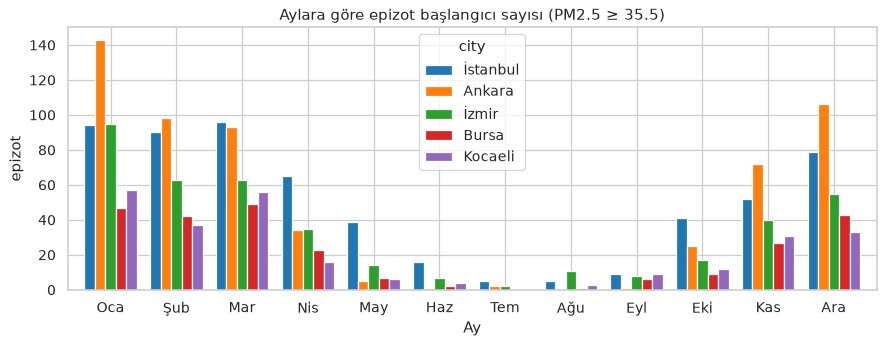

In [15]:
m = pd.concat(starts_all).groupby(["month", "city"]).size().unstack(1).reindex(range(1, 13)).fillna(0)
fig, ax = plt.subplots(figsize=(10, 4))
m[[CITY_LABEL[c] for c in CITY_ORDER]].plot.bar(ax=ax, color=[PALETTE[c] for c in CITY_ORDER], width=0.8)
ax.set(title=f"Aylara göre epizot başlangıcı sayısı (PM2.5 ≥ {SENSITIVE})", xlabel="Ay", ylabel="epizot")
ax.set_xticklabels(["Oca", "Şub", "Mar", "Nis", "May", "Haz", "Tem", "Ağu", "Eyl", "Eki", "Kas", "Ara"], rotation=0)
fig.tight_layout()
save(fig, "11_epizot_aylar")

In [16]:
rows = {}
for c in CITY_ORDER:
    s = by_city[c][TARGET]
    now, later = s >= SENSITIVE, (s.shift(-24) >= SENSITIVE)
    valid = s.shift(-24).notna()
    now, later = now[valid], later[valid]
    rows[CITY_LABEL[c]] = {"taban oran %": later.mean() * 100,
                           "P(24s sonra uyarı | şimdi uyarı) %": later[now].mean() * 100,
                           "P(24s sonra uyarı | şimdi yok) %": later[~now].mean() * 100,
                           "yeni başlayan uyarı payı %": (~now[later]).mean() * 100}
print("Uyarı = PM2.5 ≥ 35,5 µg/m³. 'Yeni başlayan uyarı payı': 24 saat sonraki uyarıların")
print("şu an uyarı OLMAYAN saatlerden gelen kısmı; persistence modelinin kaçıracağı oran.")
pd.DataFrame(rows).T

Uyarı = PM2.5 ≥ 35,5 µg/m³. 'Yeni başlayan uyarı payı': 24 saat sonraki uyarıların
şu an uyarı OLMAYAN saatlerden gelen kısmı; persistence modelinin kaçıracağı oran.


,taban oran %,P(24s sonra uyarı | şimdi uyarı) %,P(24s sonra uyarı | şimdi yok) %,yeni başlayan uyarı payı %
İstanbul,13.95,47.99,8.40,51.79
Ankara,11.98,62.92,5.03,36.90
İzmir,7.06,41.54,4.43,58.26
Bursa,4.37,37.17,2.87,62.75
Kocaeli,4.75,35.96,3.18,63.69


## 12. Özet bulgular ve modelleme kararları

| # | Bulgu | Kanıt | Karar |
|---|---|---|---|
| 1 | **Hedef sağa çarpık** | Çarpıklık ham 1,4–3,2; `log1p` sonrası 0,0–0,7 | Faz 3'te ham hedef ile `log1p` hedef karşılaştırılacak |
| 2 | **Güçlü mevsimsellik** | Kış/yaz medyan oranı: Ankara 2,65, İstanbul 1,87 … Bursa 1,18. Uyarı epizotlarının %70–88'i Kasım–Mart'ta başlıyor | Ay için döngüsel özellikler. **Walk-forward test pencereleri mutlaka kış aylarını da kapsamalı**; metrikler mevsime göre de raporlanmalı |
| 3 | **Kışın belirgin günlük döngü** | Kış zirvesi 20:00–22:00, dip 13:00–15:00; zirve/dip oranı 2,4–4,3 (Ankara en yüksek) | Saat özellikleri kritik; akşam ısınması ve gece sığlaşan sınır tabakası muhtemel nedenler |
| 4 | **Hafta sonu etkisi (küçük)** | Cumartesi–Pazar hafta ortalamasının %3–9 altında, zirve Çarşamba–Perşembe | `dayofweek` / `is_weekend` kalsın; resmî tatiller Faz 2.2'de eklenecek |
| 5 | **Rüzgâr hızı en güçlü meteorolojik etken** | Durgun havada (<2 km/sa) medyan PM2.5, 20 km/sa üstüne göre 2,4–3,1 kat yüksek; ρ = −0,52 | Rüzgâr hızının kayan ortalamaları ve "son N saatteki durgun saat sayısı" özelliği denenecek |
| 6 | **Rüzgâr yönü şehre özgü** | İstanbul'da DGD rüzgârında ort. 43,7, KD'da 15,6 µg/m³ (~2,8 kat). Ankara ve İzmir'de doğu, Kocaeli'de KB kirli | Rüzgâr u/v bileşenleri zaten var; şehir kodu ile birlikte ağaç modelleri bu etkileşimi öğrenebilir |
| 7 | **Yağış temizliyor** | Son 3 saatte yağış olduğunda medyan %17–25 düşük | Yağışın 3/6/24 saatlik toplamları özellik olacak |
| 8 | **Kirleticiler birlikte hareket ediyor** | PM10 ile ρ = 0,96; SO₂, NO₂, CO ile 0,72–0,75 (yanma kaynaklı ortak emisyon); ozonla −0,59 | Diğer kirleticilerin **geçmiş** değerleri özellik olarak eklenecek. Eşzamanlı değerler tahmin anında bilinmediği için kullanılmayacak |
| 9 | **Otokorelasyon 24 saatte yeniden yükseliyor** | ACF: lag 1 ≈ 0,96, lag 12 ≈ 0,41–0,50, lag 24 ≈ 0,60–0,75, lag 168 ≈ 0,28–0,52 | Lag 1, 2, 3, 24, 48, 168 seçimi doğrulandı. 24 saatlik tahminin zor kısmı aradaki 12 saatlik düşüş |
| 10 | **Şehirler arası öncül ilişki zayıf** | En güçlü 10 şehir çiftinde anomali korelasyonu 0,50–0,58 ama en iyi gecikme 0–2 saat; 24 saat gecikmede 0,31–0,42'ye düşüyor | Diğer şehirlerin geçmiş değerleri düşük öncelikli; en fazla "bölgesel ortalama anomali" tek özellik olarak denenebilir |
| 11 | **Epizotlar kısa ve yeni başlayanlar çoğunlukta** | Epizot medyan süresi 4–5 saat (%90: 12–17 saat). 24 saat sonraki uyarı saatlerinin %37–64'ü şu an uyarı olmayan saatlerden geliyor | Persistence bu uyarıların çoğunu kaçırır. Uyarının başlangıcını yakalamak için **meteoroloji belirleyici**: gelecek hava tahmini özelliği (Faz 3.5) yüksek öncelikli |
| 12 | **Uyarı eşiği** | ≥35,5 µg/m³ saatler %4–14, ≥55,5 saatler %0,3–5,4 | Ana uyarı eşiği **35,5 (Hassas gruplar için sağlıksız)** olarak önerilir; 55,5 ikinci kademe |

**Sınırlamalar.** Veri CAMS model çıktısıdır. Bursa'daki zayıf mevsimsellik (bulgu 2), modelin ~11 km
çözünürlüğünün yerel kış kirliliğini yakalayamadığına işaret ediyor olabilir. Bulgular gerçek
istasyon ölçümleriyle doğrulanmamıştır.